# REXAI Project - Session 1

## 1. Importing Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Data Exploration and Visualization

In [3]:
df = pd.read_csv("data/RH_dataset.csv", sep=";", encoding="utf-8")
df.head()

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  object 
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  object 
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  l

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=[object]).columns
assert len(num_cols) + len(cat_cols) == df.shape[1], "Some columns are not categorized correctly."

In [6]:
col_to_category = {}
for col in cat_cols:
    unique_values = df[col].unique().tolist()
    col_to_category[col] = unique_values
    print(f"Column: {col}, Unique Values: {unique_values}")

Column: Famille d'emploi, Unique Values: ['Production', 'Commercial/Business', 'Etudes & Technique', 'Support', 'IT', 'Développement Immobilier', 'Matériel/Equipement', 'Management']
Column: Statut marital, Unique Values: ['Marié(e)', 'PACS', 'Célibataire', 'Divorcé(e)', 'Union libre', 'Concubin', 'Séparé(e)', 'Veuf(ve)', 'ex PACS']


In [7]:
# Hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
df_encoded.head()

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,...,Famille d'emploi_Support,Statut marital_Concubin,Statut marital_Célibataire,Statut marital_Divorcé(e),Statut marital_Marié(e),Statut marital_PACS,Statut marital_Séparé(e),Statut marital_Union libre,Statut marital_Veuf(ve),Statut marital_ex PACS
0,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,0,...,0,0,0,0,1,0,0,0,0,0
1,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,1,...,0,0,0,0,1,0,0,0,0,0
2,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,1,...,0,0,0,0,0,1,0,0,0,0
3,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,0,...,0,0,1,0,0,0,0,0,0,0
4,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,1,...,0,0,0,0,1,0,0,0,0,0


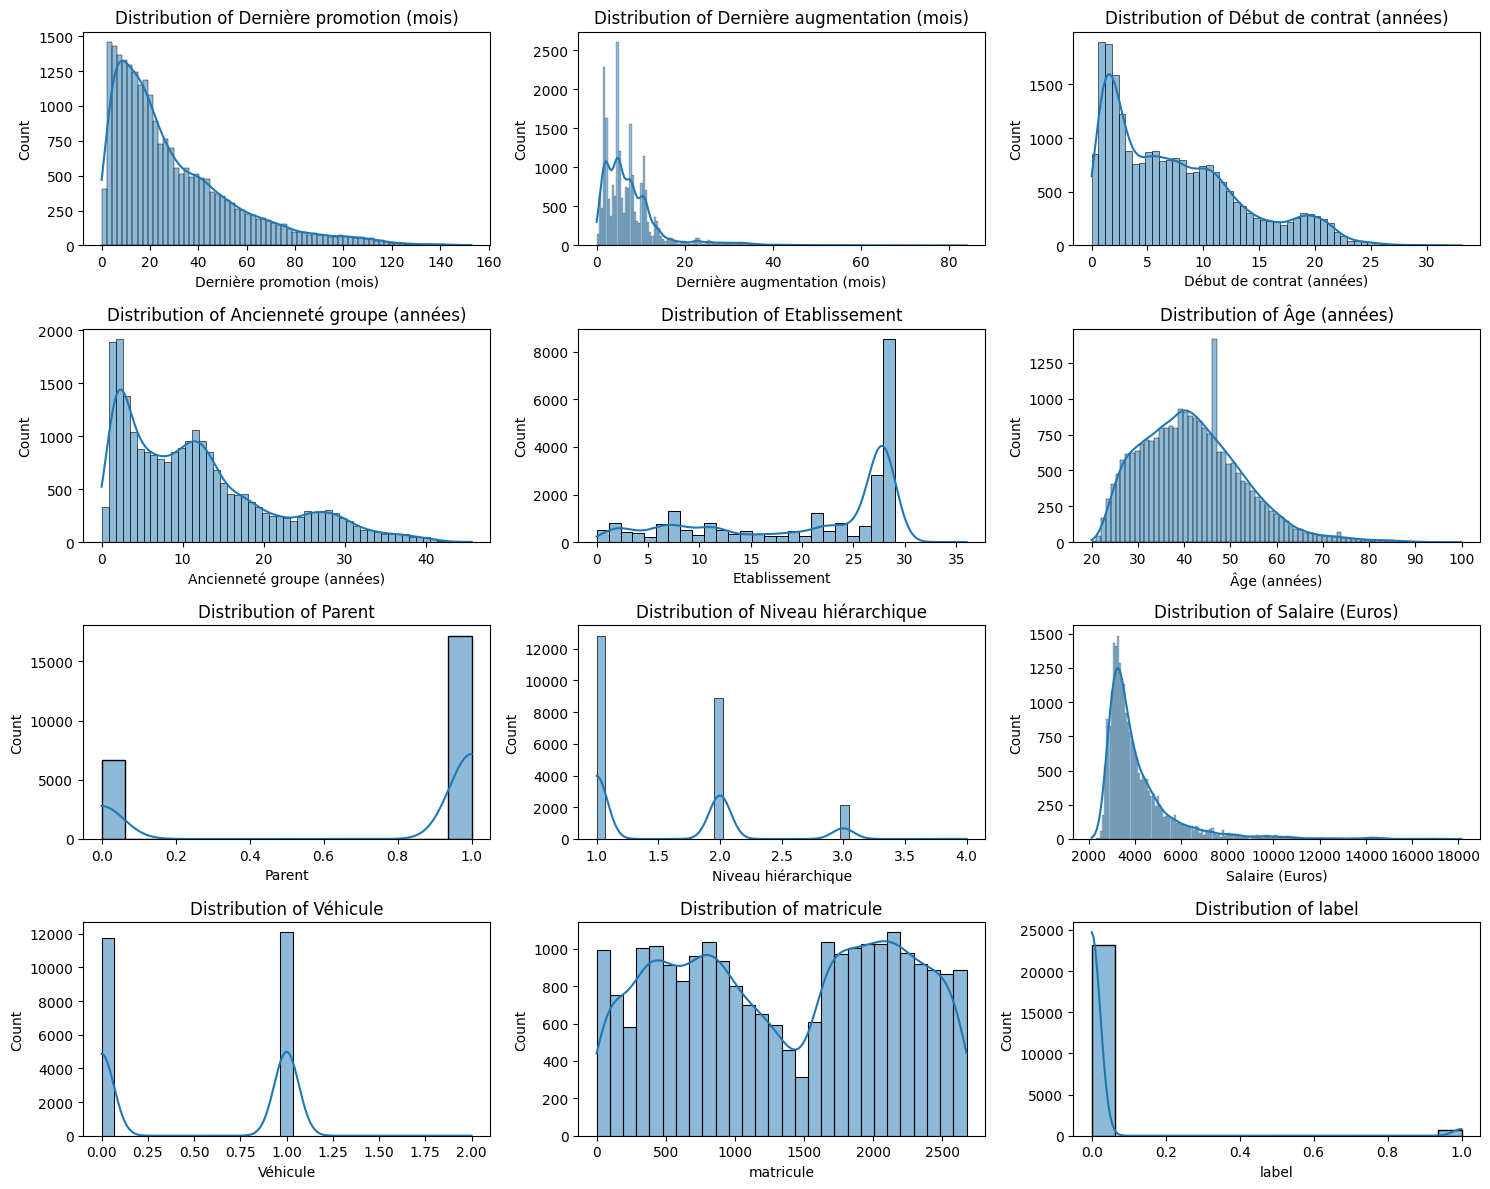

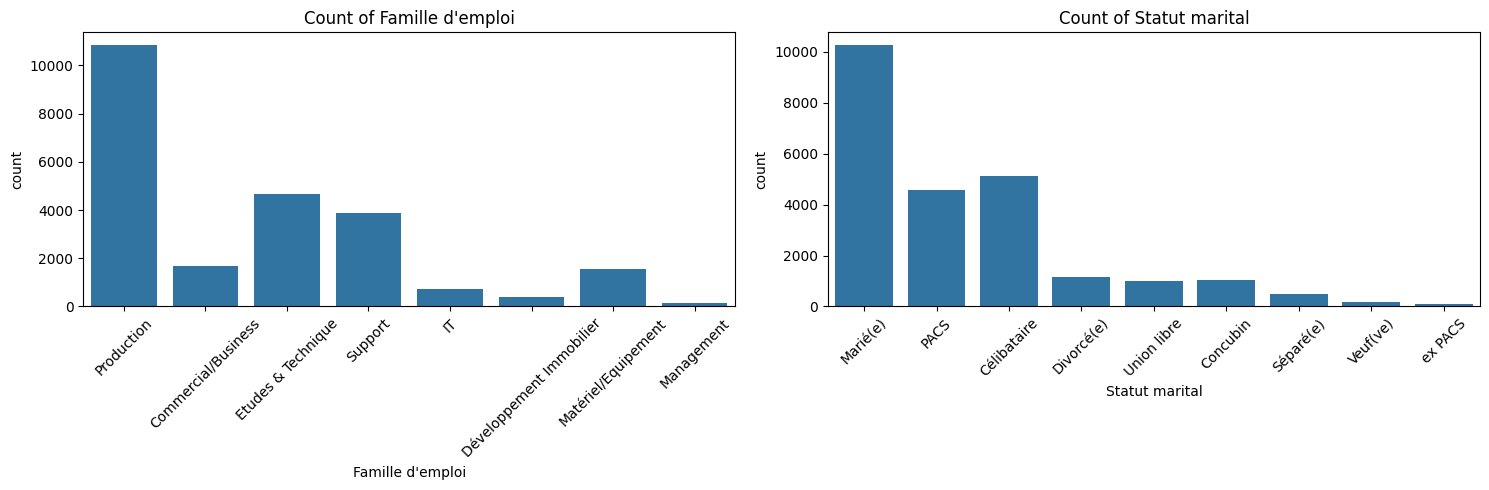

In [8]:
# Plot on the same figure in grid mode
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Show histograms for categorical variables
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(15, 5))
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

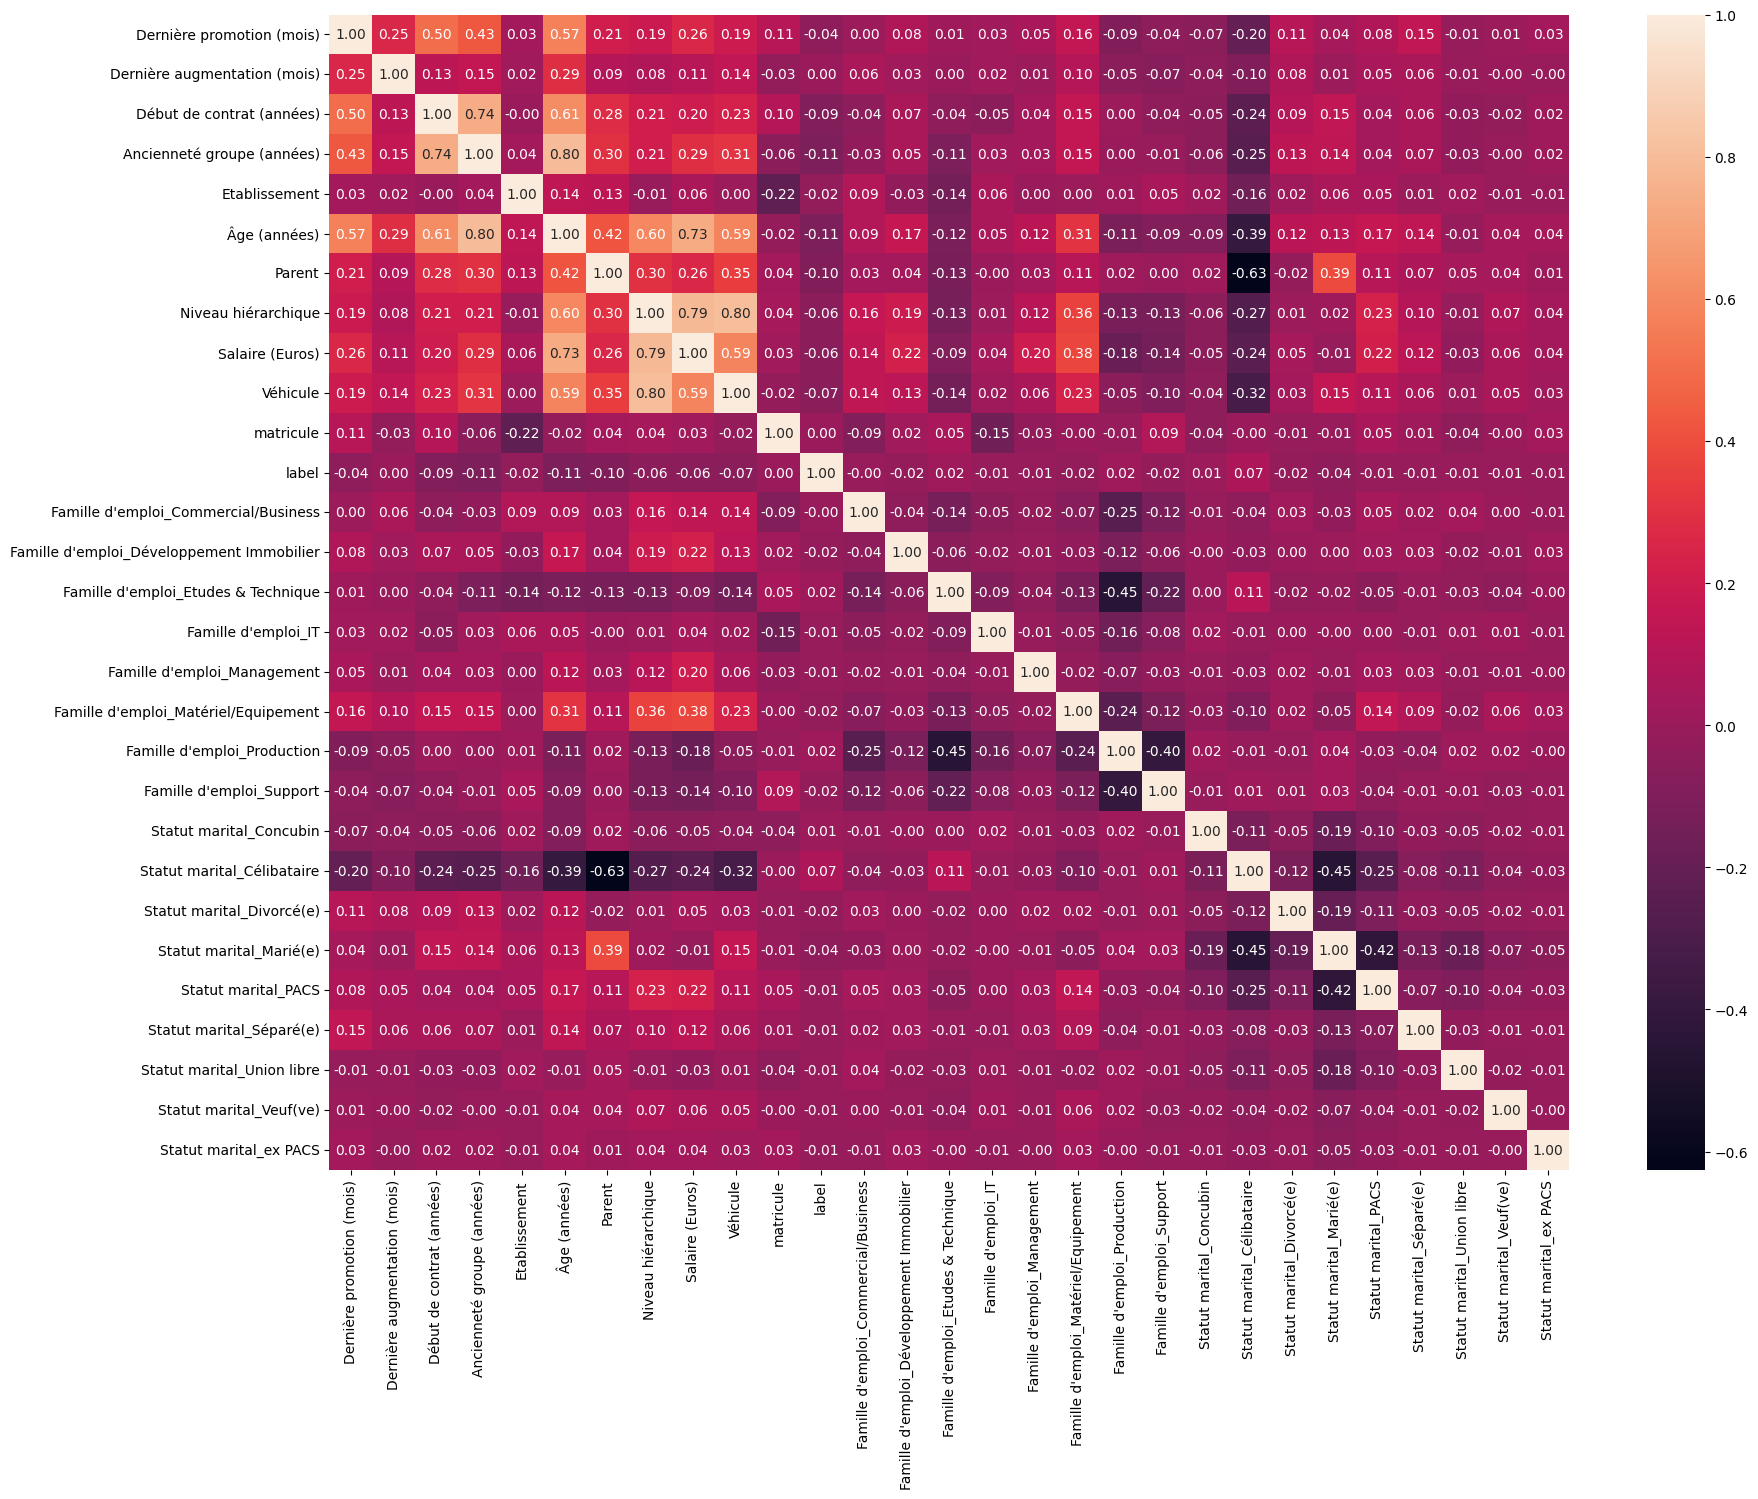

In [9]:
# Increase figure size for better readability
plt.figure(figsize=(20, 15))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f")
plt.show()

- Indiquez par exemple si le jeu de données contient des données manquantes, explorez les différentes colonnes (type, modalités, plages de valeurs, cardinal, distributions, etc.). Commenter.
- Exhibez le parcours d’un employé qui a démissionné et celui d’un employé qui n’a pas démissionné. Commenter.
- Affichez la matrice de corrélation. Commenter.
- Toute autre analyse

- Identifier les variables pouvant être considérées comme sensibles ou
proxies, i.e. des variables qui permettent de deviner ou d’inférer des
caractéristiques sensibles (e.g. la variable temps de pause maternité peut
potentiellement révéler le sexe). (Justifier votre réponse et classification)

## Parcours employés
- Exhibez le parcours d’un employé qui a démissionné et celui d’un employé qui n’a pas démissionné.
- Stats sur les employés en fonction du label

In [10]:
df_resign = df[df.label == 1]
df_no_resign = df[df.label == 0]
df_resign_encoded = df_encoded[df_encoded.label == 1]
df_no_resign_encoded = df_encoded[df_encoded.label == 0]

print(f"Nombre d'employés ayant démissioné: {len(df_resign)}")
print(f"Nombre d'employés n'ayant pas démissioné: {len(df_no_resign)}")

Nombre d'employés ayant démissioné: 755
Nombre d'employés n'ayant pas démissioné: 23102


### Comparaison distributions numériques par label

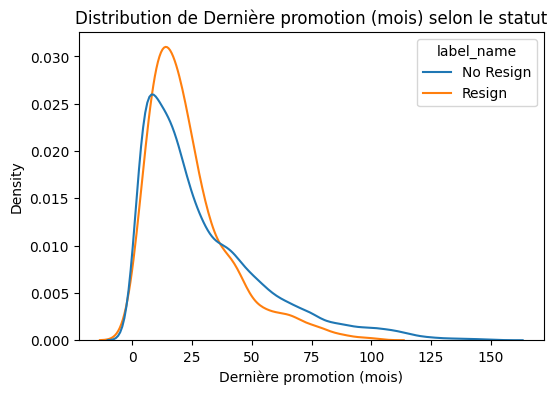

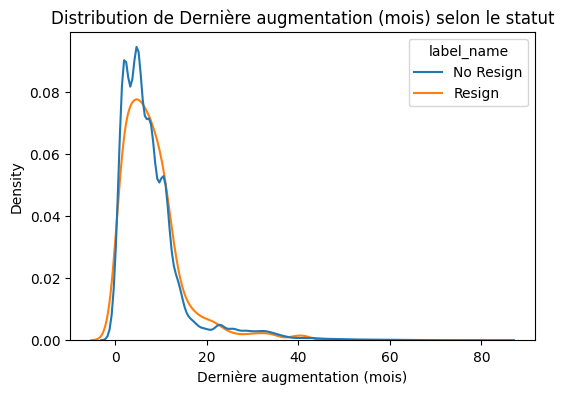

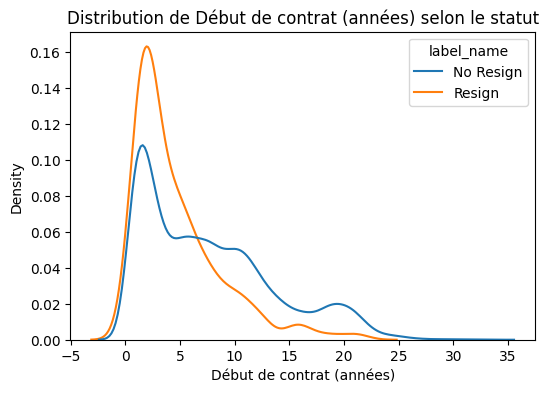

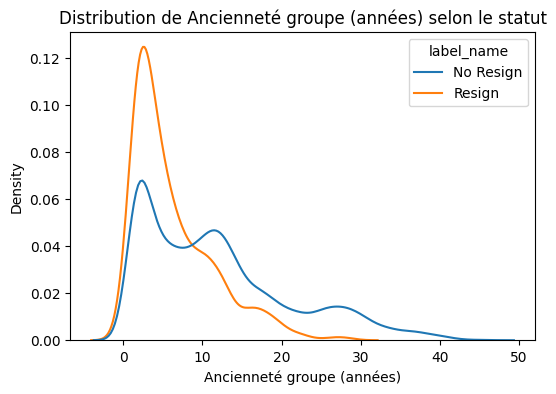

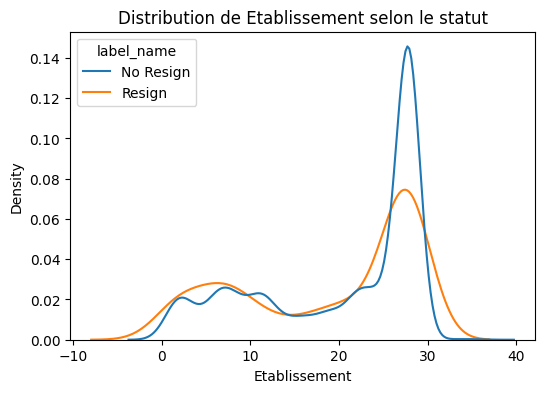

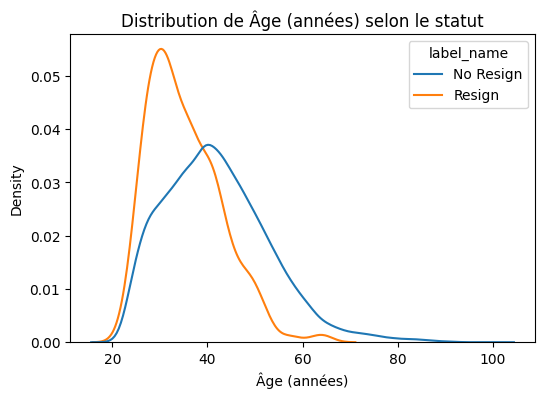

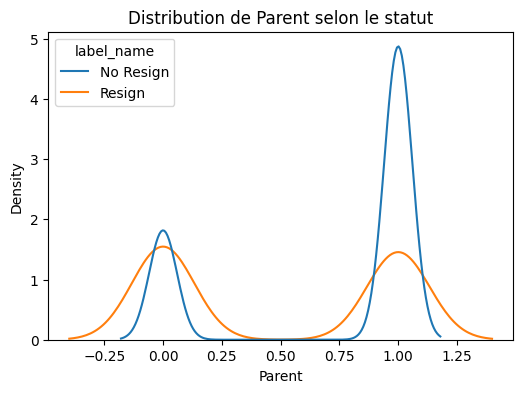

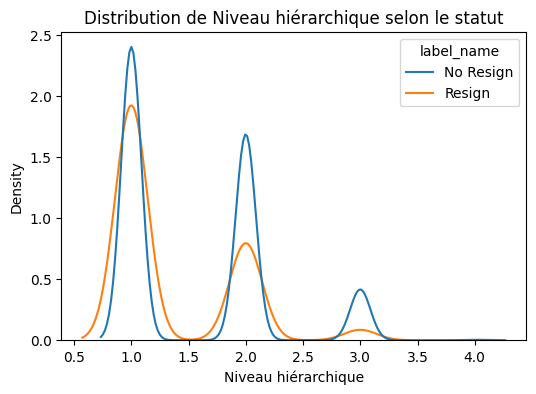

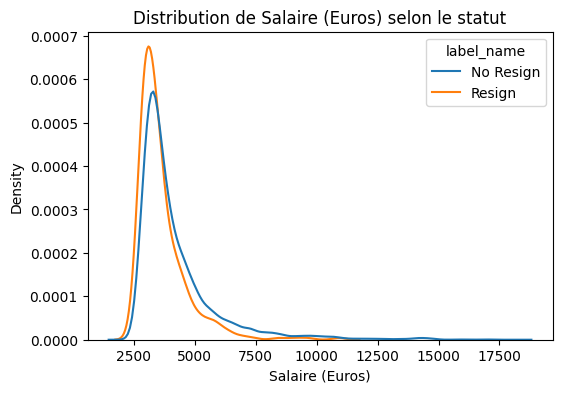

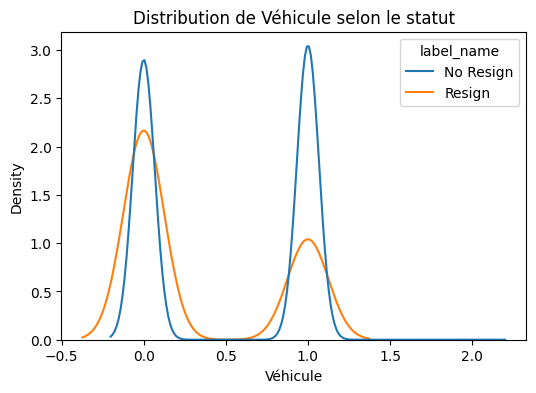

In [11]:
for col in num_cols.drop(["label","matricule"]):
    
    plt.figure(figsize=(6,4))
    
    sns.kdeplot(
        data=df.assign(label_name=df["label"].map({0:"No Resign",1:"Resign"})),
        x=col,
        hue="label_name",
        common_norm=False
    )
    
    plt.title(f"Distribution de {col} selon le statut")
    plt.show()

### Comparaison médianes et dispersion

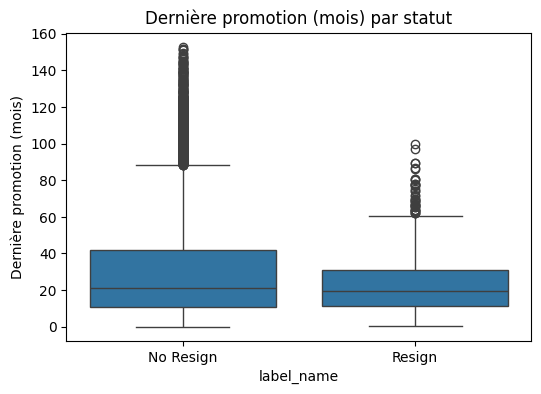

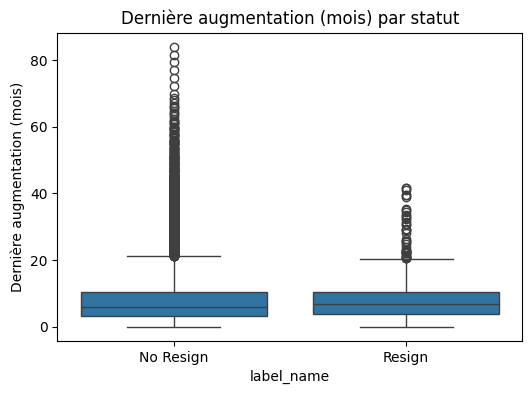

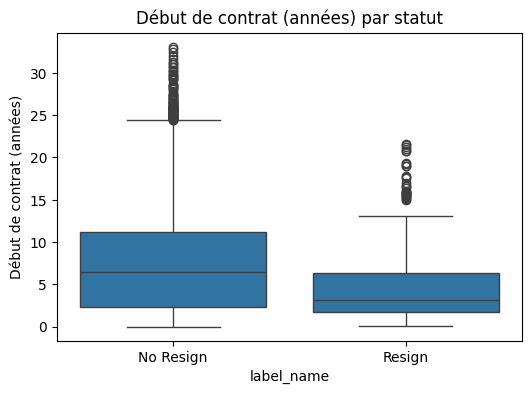

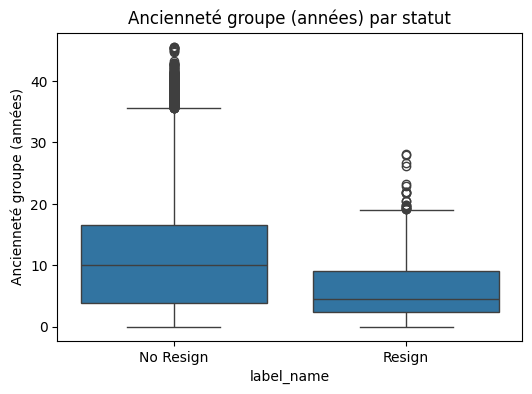

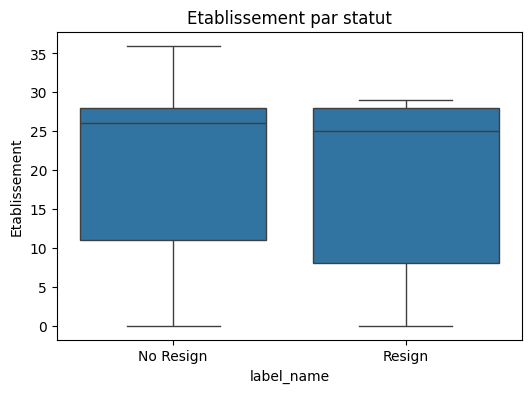

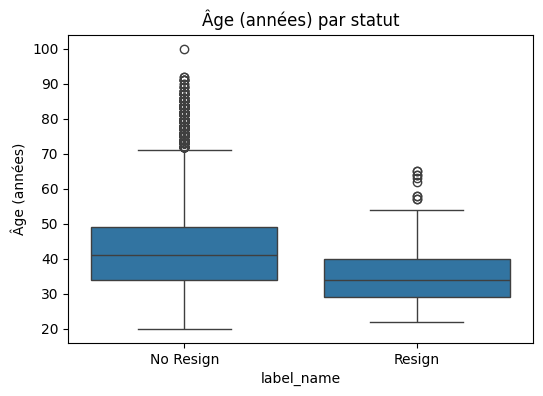

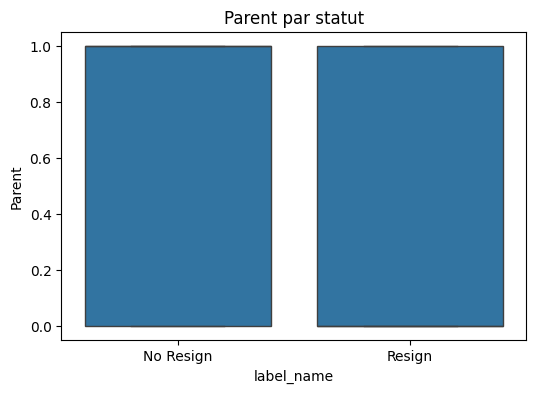

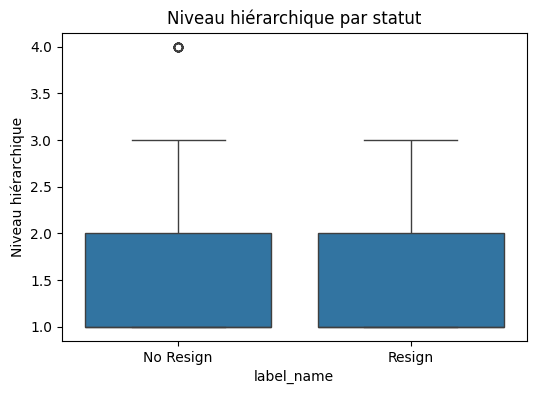

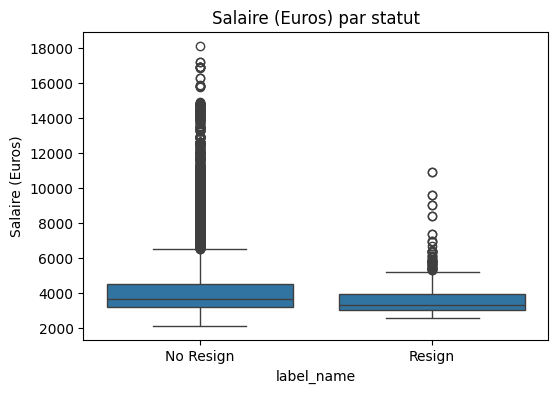

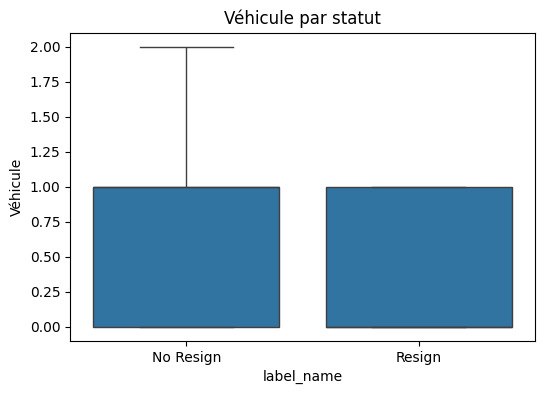

In [12]:
for col in num_cols.drop(["label","matricule"]):

    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        data=df.assign(label_name=df["label"].map({0:"No Resign",1:"Resign"})),
        x="label_name",
        y=col
    )
    
    plt.title(f"{col} par statut")
    plt.show()

### Analyse des variables catégorielles

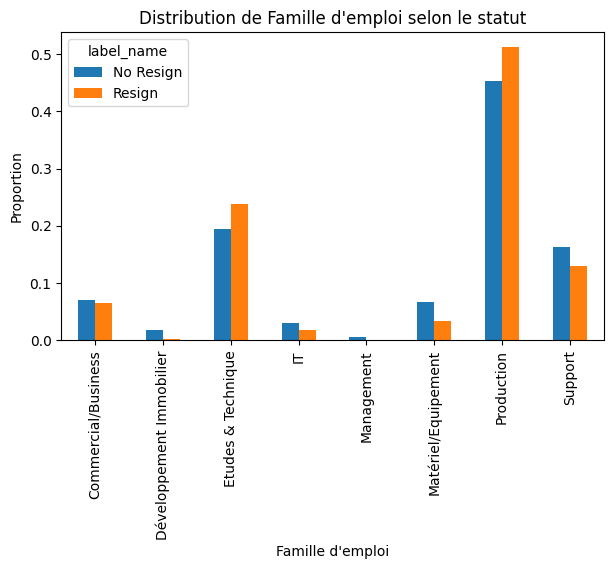

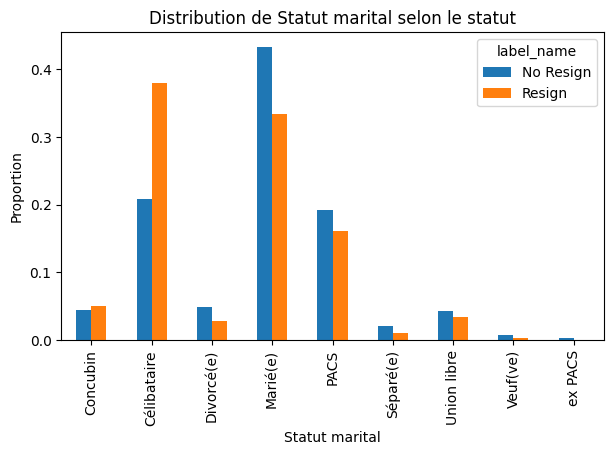

In [13]:
for col in cat_cols:
    
    temp = df.assign(label_name=df["label"].map({0:"No Resign",1:"Resign"}))
    
    counts = (
        temp.groupby(["label_name", col])
        .size()
        .unstack(fill_value=0)
    )
    
    prop = counts.div(counts.sum(axis=1), axis=0)
    
    prop.T.plot(kind="bar", figsize=(7,4))
    
    plt.title(f"Distribution de {col} selon le statut")
    plt.ylabel("Proportion")
    plt.show()

### Salaire vs. Ancienneté

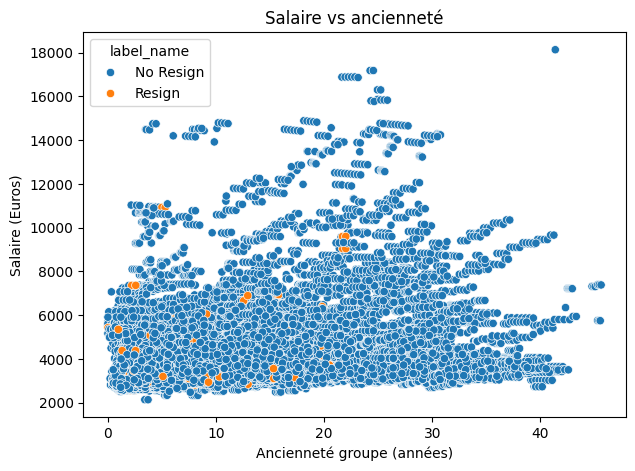

In [14]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df.assign(label_name=df["label"].map({0:"No Resign",1:"Resign"})),
    x="Ancienneté groupe (années)",
    y="Salaire (Euros)",
    hue="label_name"
)

plt.title("Salaire vs ancienneté")
plt.show()

### Profil moyen des démissionnaires

In [15]:
df_resign.head()

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
3,Production,5.240000,5.10,1.02,1.75,27,24,0,1,2641,Célibataire,0,2619,1
59,Production,3.820000,3.32,0.65,3.35,28,27,0,1,2853,Marié(e),0,2584,1
64,Support,8.150000,10.08,3.67,3.69,26,27,0,1,2603,PACS,0,508,1
73,Production,11.450000,10.07,6.68,10.27,8,35,0,1,3338,Concubin,0,1956,1
75,Etudes & Technique,22.379999,22.15,2.47,2.63,28,33,0,1,3088,Célibataire,0,2630,1


In [16]:
profile_resign = df_resign.iloc[:, df.columns != 'label'].describe().T
profile_no_resign = df_no_resign.iloc[:, df.columns != 'label'].describe().T

comparison = pd.DataFrame({
    "Resign_mean": profile_resign["mean"],
    "No_resign_mean": profile_no_resign["mean"]
})

comparison["difference"] = comparison["Resign_mean"] - comparison["No_resign_mean"]

comparison.sort_values("difference", key=abs, ascending=False)

,Resign_mean,No_resign_mean,difference
Salaire (Euros),3635.705960,4185.813220,-550.107259
Âge (années),35.270199,41.979482,-6.709284
Dernière promotion (mois),23.845894,29.644239,-5.798345
Ancienneté groupe (années),6.245868,11.808123,-5.562256
matricule,1365.797351,1361.107437,4.689914
Début de contrat (années),4.673563,7.623685,-2.950122
Etablissement,18.950993,20.234568,-1.283575
Parent,0.484768,0.728422,-0.243654
Niveau hiérarchique,1.344371,1.561423,-0.217052
Véhicule,0.324503,0.512813,-0.188309


Démission dans les 6 mois

In [17]:
sample_resign = df_resign.sample(random_state=42)
sample_resign

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
9416,Etudes & Technique,25.559999,4.54,3.22,3.31,26,29,0,1,2752,Union libre,0,17,1


In [18]:
df_resign[num_cols.drop(["label","matricule", "Etablissement"])].describe()

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule
count,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000
mean,23.845894,8.060728,4.673563,6.245868,35.270199,0.484768,1.344371,3635.705960,0.324503
std,17.400095,6.594335,4.034534,5.097133,7.657011,0.500099,0.535805,1035.558766,0.468499
min,0.280000,0.000000,0.100000,0.000000,22.000000,0.000000,1.000000,2561.000000,0.000000
25%,11.460000,3.895000,1.770000,2.360000,29.000000,0.000000,1.000000,3001.000000,0.000000
50%,19.350000,6.890000,3.200000,4.480000,34.000000,0.000000,1.000000,3338.000000,0.000000
75%,31.179999,10.510000,6.315000,9.075000,40.000000,1.000000,2.000000,3915.000000,1.000000
max,99.680000,41.709999,21.590000,28.070000,65.000000,1.000000,3.000000,10927.000000,1.000000


Pas de démission dans les 6 mois

In [19]:
sample_no_resign = df_no_resign.sample(random_state=42)
sample_no_resign

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
22854,Support,9.37,4.78,2.3,2.45,28,31,1,1,3283,Marié(e),0,1163,0


In [20]:
df_no_resign[num_cols.drop(["label","matricule", "Etablissement"])].describe()

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule
count,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000
mean,29.644239,7.930876,7.623685,11.808123,41.979482,0.728422,1.561423,4185.813220,0.512813
std,25.699102,7.579271,6.015819,9.270018,11.042857,0.444783,0.660378,1671.420167,0.500193
min,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.000000,2134.000000,0.000000
25%,10.550000,3.142500,2.330000,3.920000,34.000000,0.000000,1.000000,3203.000000,0.000000
50%,21.299999,5.850000,6.430000,10.080000,41.000000,1.000000,1.000000,3640.500000,1.000000
75%,41.689999,10.330000,11.190000,16.607501,49.000000,1.000000,2.000000,4536.750000,1.000000
max,152.970001,84.050003,33.119999,45.619999,100.000000,1.000000,4.000000,18137.000000,2.000000


## 3.Machine Learning Models

### Logistic Regression

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

**Sans pondérations des labels**

In [22]:
X = df_encoded.drop(columns=["label", "matricule", "Etablissement"])
y = df_encoded.label

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4621
           1       0.00      0.00      0.00       151

    accuracy                           0.97      4772
   macro avg       0.48      0.50      0.49      4772
weighted avg       0.94      0.97      0.95      4772

ROC AUC: 0.7289683864763654


/home/augustin/.pyenv/versions/rexia/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/augustin/.pyenv/versions/rexia/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/augustin/.pyenv/versions/rexia/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

Sans pondérer les classes, le classifier prédit tous les labels à 0 (ce qui est souvent vrai étant donné la forte présence de label=0)

**Sans one-hot encoding _Etablissement_**

In [24]:
X = df_encoded.drop(columns=["label", "matricule", "Etablissement"])
y = df_encoded.label

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      0.60      0.74      4621
           1       0.06      0.74      0.10       151

    accuracy                           0.60      4772
   macro avg       0.52      0.67      0.42      4772
weighted avg       0.96      0.60      0.72      4772

ROC AUC: 0.7254959005175049


**Avec one-hot encoding _Etablissement_**

In [26]:
X_etablissement = pd.get_dummies(df_encoded, columns=["Etablissement"], drop_first=False, dtype=int)
X = X_etablissement.drop(columns=["label", "matricule"])
y = df_encoded.label

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      0.62      0.76      4621
           1       0.06      0.77      0.11       151

    accuracy                           0.62      4772
   macro avg       0.53      0.70      0.44      4772
weighted avg       0.96      0.62      0.74      4772

ROC AUC: 0.7544867872124235


Le fait d'ajouter l'établissement permet d'améliorer légèrement le recall, sans dégrader les autres indicateurs.

Au global, on a une très mauvaise précision sur la classe 1 (démission). Cela peut s'expliquer pas la faible proportion de label 1.

In [28]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

def fairness_evaluation_with_trueDI(y_true, y_pred, X, age_bins=[20,40,60,80,100]):    
    df_eval = X.copy()
    df_eval['y_true'] = y_true
    df_eval['y_pred'] = y_pred
    
    # Tranches d'âge
    age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins)-1)]
    df_eval['Âge (années)'] = pd.cut(df_eval['Âge (années)'], bins=age_bins, labels=age_labels)
    
    results = {}
    
    # Sous-groupes
    subgroups = {
        'Parent': df_eval['Parent'].unique(),
        'Âge (années)': df_eval['Âge (années)'].unique()
    }
    
    # Calcul metrics
    for group_col, groups in subgroups.items():
        metrics = []
        privileged_group = groups[0]  # référence pour DI
        
        for g in groups:
            sub = df_eval[df_eval[group_col]==g]
            if len(sub)==0:
                continue
            
            # FPR / FNR
            tn, fp, fn, tp = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0,1]).ravel()
            fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
            fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
            
            # Disparate Impact sur prédiction
            p_priv_pred = df_eval[df_eval[group_col]==privileged_group]['y_pred'].mean()
            p_unpriv_pred = sub['y_pred'].mean()
            di_pred = p_unpriv_pred / p_priv_pred if p_priv_pred > 0 else np.nan
            
            # Disparate Impact sur vrai label
            p_priv_true = df_eval[df_eval[group_col]==privileged_group]['y_true'].mean()
            p_unpriv_true = sub['y_true'].mean()
            di_true = p_unpriv_true / p_priv_true if p_priv_true > 0 else np.nan
            
            metrics.append({
                'group': g,
                'count': len(sub),
                'FPR': fpr,
                'FNR': fnr,
                'DI_pred': di_pred,
                'DI_true': di_true
            })
        
        results[group_col] = pd.DataFrame(metrics)
    
    return results

In [172]:
results = fairness_evaluation_with_trueDI(y_test, y_pred, X_test[['Parent','Âge (années)']])

for group_col, df_metrics in results.items():
    print(f"\n{group_col}")
    print(df_metrics.to_string(index=False))


Parent
 group  count      FPR      FNR  DI_pred  DI_true
     1   3464 0.272727 0.415385 1.000000 1.000000
     0   1308 0.689034 0.081395 2.527566 3.503928

Âge (années)
 group  count      FPR      FNR  DI_pred  DI_true
 40-60   2176 0.129439 0.611111 1.000000 1.000000
 60-80    244 0.004132 1.000000 0.030646 0.495446
 20-40   2332 0.671924 0.088496 5.111233 2.928912
80-100     19 0.000000      NaN 0.000000 0.000000


Le modèle semble d'avantage discriminer les 20-40 ans par rapport à la réalité (5 fois plus de démission que les 40-60 ans prédit, contre seulement 3 fois plus en réalité).
Il discrimine aussi plus les parents.

**Explication post-hoc**

In [50]:
logreg_model = pipeline.named_steps["model"]

coef = logreg_model.coef_[0]
features = X_train.columns

n=len(y_test)
residuals = y_test - y_pred
residual_sum_of_squares = residuals.T @ residuals
sigma_squared_hat = residual_sum_of_squares / (n - 2)
var_beta = np.array([1/np.sum([(X_test[col].to_numpy()[j] - np.mean(X_test[col]))**2 for j in range(n)]) * sigma_squared_hat for col in features])
SE_beta = np.sqrt(var_beta)
t_beta = coef/SE_beta

print(f"{'Feature':<40} {'Weight':>12} {'SE':>12} {'|t|':>12}")
print("-" * 60)

for col, i in zip(features, range(len(features))):
    print(f"{col:<40} {coef[i]:>12.6f} {SE_beta[i]:>12.6f} {abs(t_beta[i]):>12.6f}")

Feature                                        Weight           SE          |t|
------------------------------------------------------------
Dernière promotion (mois)                    0.369355     0.000359  1028.963124
Dernière augmentation (mois)                 0.151118     0.001163   129.911060
Début de contrat (années)                   -0.109496     0.001472    74.403376
Ancienneté groupe (années)                  -0.518064     0.000956   541.711368
Âge (années)                                -0.661925     0.000811   815.901788
Parent                                      -0.201094     0.019952    10.078660
Niveau hiérarchique                         -0.187634     0.013619    13.777829
Salaire (Euros)                              0.244913     0.000005 46099.468433
Véhicule                                     0.133188     0.017804     7.480771
Famille d'emploi_Commercial/Business         0.001911     0.034139     0.055990
Famille d'emploi_Développement Immobilier    -0.198154     

On observe un impact très fort des features suivantes :
- Dernière promotion
- Dernière augmentation
- Début du contrat
- Ancienneté
- Âge
- Salaire

In [51]:
X = df_encoded[["Dernière promotion (mois)", "Dernière augmentation (mois)", "Début de contrat (années)", "Ancienneté groupe (années)", "Âge (années)", "Salaire (Euros)"]]
y = df_encoded.label

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      0.60      0.74      4621
           1       0.06      0.73      0.10       151

    accuracy                           0.60      4772
   macro avg       0.52      0.66      0.42      4772
weighted avg       0.96      0.60      0.72      4772

ROC AUC: 0.7061772415305307


On arrive à garder des bonnes performances avec un modèle à seulement 6 features (contre 61 dans le modèle avec le one-hot encoding de Etablissement).